In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    "text.usetex": True,
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

In [6]:
data = np.loadtxt("./Data-20261006/01.dat")

V_GS = data[:, 0]
I_DS = data[:, 1]
V_DS = data[:, 2]
V_C = 0.5 * (data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = -data[:, 7]
V_del = -(V_GS - V_C)

# plt.plot(
#     V_del,
#     sigma * 1e6,
#     color='red',
#     marker='o',
#     markevery=1,
#     ls='-',
#     markeredgecolor="white", markeredgewidth=1, markersize=7
#     )

# plt.xlabel(r"$V_{GS} - V_C$ (V)")
# plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
# plt.title("Conductivity vs. Gate Voltage")
# plt.show()

C = 1.8e-9
A = 32e-6
Ci = C / A

In [7]:
def func(x, a, b):
    return a*x + b

mask = (V_del > 57) & (V_del < 100)


popt, pcov = curve_fit(func, V_del[mask], sigma[mask])
sigma_fit = func(V_del, *popt)
a = popt[0]
b = popt[1]

mu = a / Ci * 1e4
V_T = -b / a

print(f"Mobility (μ): {mu:.2f} cm^2/Vs")
print(f"Threshold Voltage (V_T): {V_T:.2f} V")



# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))

plt.plot(
    V_del,
    sigma * 1e6,
    color='red',
    marker='o',
    markevery=1,
    ls='-',
    label='Data',
    markeredgecolor="white", markeredgewidth=1, markersize=7
    )
plt.plot(
    V_del,
    sigma_fit * 1e6,
    color='blue',
    ls='-',
    label=f'Fit'
    )
plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
plt.title("Conductivity vs. Gate Voltage with Fit")
plt.xlim(40,100)
plt.ylim(0, sigma.max() * 1e6 * 1.1)  # Convert to μS/sq. for y-axis limits
plt.legend(numpoints=1)
plt.show()




Mobility (μ): 1.80 cm^2/Vs
Threshold Voltage (V_T): 43.22 V


RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode -halt-on-error -no-shell-escape file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.4) (preloaded format=latex.fmt)
entering extended mode
(file.tex
LaTeX2e <2026-06-01>
L3 programming layer <2026-05-26>
(C:\Users\Kien.Pham\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\Kien.Pham\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))



<Figure size 1000x600 with 1 Axes>

In [8]:
T_1 = [310,300,290, 285,280,275,270,265,260]
mu_1 = [1.67,1.61,1.29, 1.09,0.78,0.48,0.27,0.16,0.09]
V_T_1 = [42.07,41.96,42.83,40.93,41.61,44.81,43.02,43.85,46.65]

T_2 = [260, 265, 270, 275, 280, 285, 290, 300, 310]
mu_2 = [0.09, 0.10, 0.12, 0.15, 0.18, 0.22, 0.30, 0.61, 1.66]
V_T_2 = [46.65, 51.16,52.49,52.53,54.82,53.61,57.84,60.03,45.81]

inv_T_1 = 1 / np.array(T_1, dtype=float)
inv_T_2 = 1 / np.array(T_2, dtype=float)
inv_T_ticks = 1 / np.array([310, 300, 290, 280, 270, 260], dtype=float)
inv_T_ticklabels = [f'1/{temp}' for temp in [310, 300, 290, 280, 270, 260]]

plt.semilogy(inv_T_1, mu_1, marker='o', linestyle='-', lw = 2, color='red',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.semilogy(inv_T_2, mu_2, marker='s', linestyle='-', lw = 2, color='blue',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Mobility $\mu$ (cm$^2$/Vs)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.title('Mobility vs. Temperature', fontsize=19)
plt.savefig('mu-1.eps', format='eps')
plt.show()

plt.plot(inv_T_1, V_T_1, marker='o', linestyle='-', lw = 2, color='red',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.plot(inv_T_2, V_T_2, marker='s', linestyle='-', lw = 2, color='blue',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Threshold Voltage $V_T$ (V)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.ylim(0, 100)  # Set y-axis limits for better visualization
plt.title('Threshold Voltage vs. Temperature', fontsize=19)
plt.savefig('VT-1.eps', format='eps')
plt.show()

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode -halt-on-error -no-shell-escape file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.4) (preloaded format=latex.fmt)
entering extended mode
(file.tex
LaTeX2e <2026-06-01>
L3 programming layer <2026-05-26>
(C:\Users\Kien.Pham\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\Kien.Pham\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))



Error in callback <function _draw_all_if_interactive at 0x000001BC468E3ED0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode -halt-on-error -no-shell-escape file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.4) (preloaded format=latex.fmt)
entering extended mode
(file.tex
LaTeX2e <2026-06-01>
L3 programming layer <2026-05-26>
(C:\Users\Kien.Pham\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\Kien.Pham\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))



RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode -halt-on-error -no-shell-escape file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.4) (preloaded format=latex.fmt)
entering extended mode
(file.tex
LaTeX2e <2026-06-01>
L3 programming layer <2026-05-26>
(C:\Users\Kien.Pham\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\Kien.Pham\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))



<Figure size 1000x600 with 1 Axes>

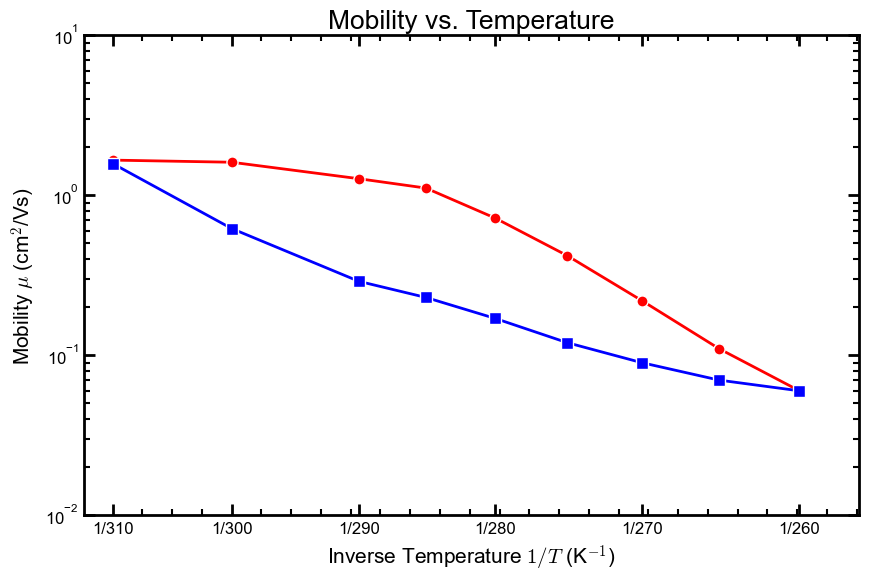

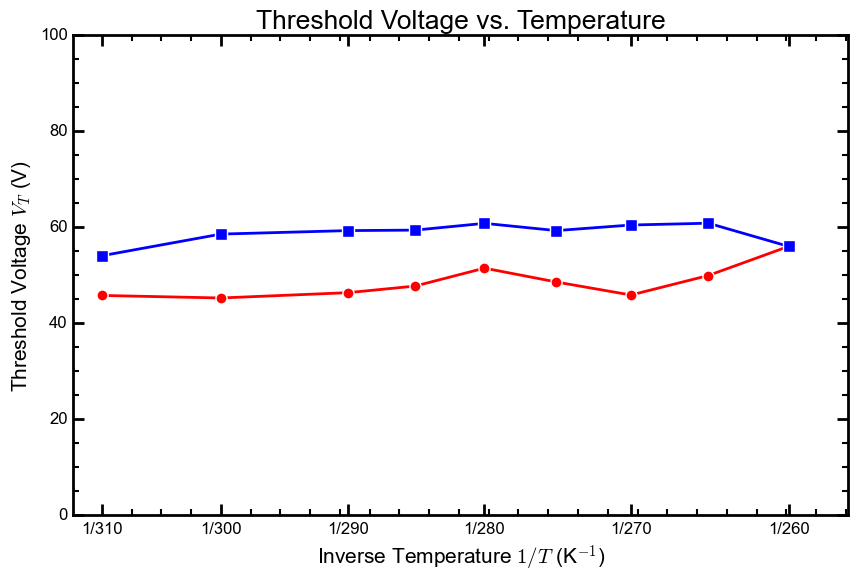

In [ ]:
T_1 = [310,300,290, 285,280,275,270,265,260]
mu_1 = [1.66,1.61,1.27,1.11,0.72,0.42,0.22,0.11, 0.06]
V_T_1 = [45.81, 45.28, 46.39, 47.76, 51.50, 48.61, 45.90, 49.96, 56.03]

T_2 = [260, 265, 270, 275, 280, 285, 290, 300, 310]
mu_2 = [0.06, 0.07, 0.09, 0.12, 0.17, 0.23, 0.29, 0.62, 1.58]
V_T_2 = [56.03, 60.86, 60.48, 59.32, 60.83, 59.42, 59.32, 58.59, 54.08]
inv_T_1 = 1 / np.array(T_1, dtype=float)
inv_T_2 = 1 / np.array(T_2, dtype=float)
inv_T_ticks = 1 / np.array([310, 300, 290, 280, 270, 260], dtype=float)
inv_T_ticklabels = [f'1/{temp}' for temp in [310, 300, 290, 280, 270, 260]]

plt.semilogy(inv_T_1, mu_1, marker='o', linestyle='-', lw = 2, color='red',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.semilogy(inv_T_2, mu_2, marker='s', linestyle='-', lw = 2, color='blue',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Mobility $\mu$ (cm$^2$/Vs)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.title('Mobility vs. Temperature', fontsize=19)
plt.savefig('mu-2.eps', format='eps')
plt.show()

plt.plot(inv_T_1, V_T_1, marker='o', linestyle='-', lw = 2, color='red',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.plot(inv_T_2, V_T_2, marker='s', linestyle='-', lw = 2, color='blue',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Threshold Voltage $V_T$ (V)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.ylim(0, 100)  # Set y-axis limits for better visualization
plt.title('Threshold Voltage vs. Temperature', fontsize=19)
plt.savefig('VT-2.eps', format='eps')
plt.show()

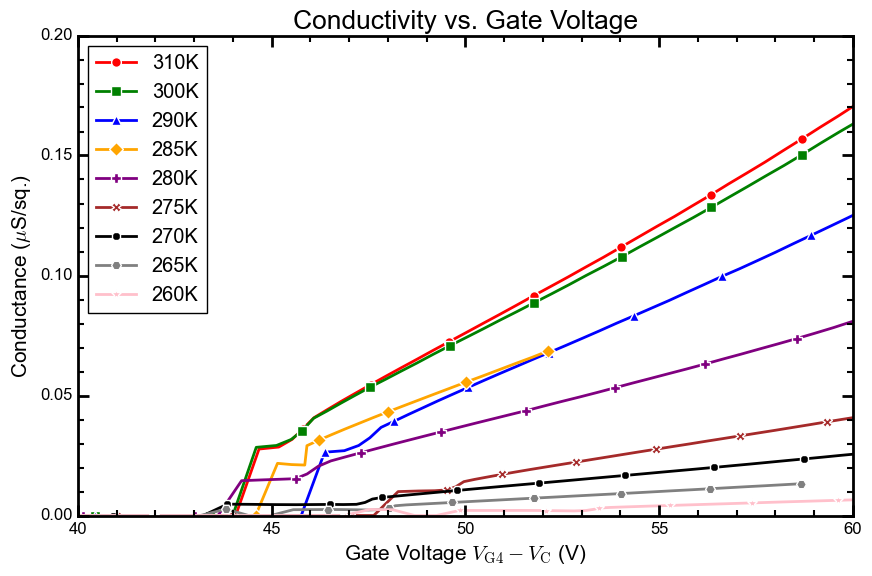

In [ ]:
from pathlib import Path

data_dir = Path("./Data-20261006")
data_files = sorted(data_dir.glob("*.dat"), key=lambda p: int(p.stem))

data_list = [np.loadtxt(file) for file in data_files]

labels = ["310K", "300K", "290K", "285K", "280K", "275K", "270K", "265K", "260K"]
colors = ["red", "green", "blue", "orange", "purple", "brown", "black", "gray", "pink"]
markers = ["o", "s", "^", "D", "P", "X", "8", "H", "*"]
mu_1 = [1.67,1.61,1.29, 1.09,0.78,0.48,0.27,0.16,0.09]
V_T_1 = [42.07,41.96,42.83,40.93,41.61,44.81,43.02,43.85,46.65]

dataset = list(zip(data_list, labels, colors, markers, mu_1, V_T_1))
for data, label, color, marker, mu, V_T in dataset:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = -data[:, 7]
    V_del = -(V_GS - V_C)

    plt.plot(
        V_del,
        sigma * 1e6,
        color=color,
        marker=marker,
        markevery=5,
        lw=2,
        ls='-',
        label=label,
        markeredgecolor="white", markeredgewidth=1, markersize=7
    )

plt.xlabel(r"Gate Voltage $V_\text{G4} - V_\text{C}$ (V)")
plt.ylabel(r"Conductance ($\mu$S/sq.)")
plt.xlim(40,60)
plt.ylim(0, 0.20)  # Adjust y-axis limits for better visualization
plt.title("Conductivity vs. Gate Voltage", fontsize=19)
plt.legend(numpoints=1, loc='upper left')
plt.show()


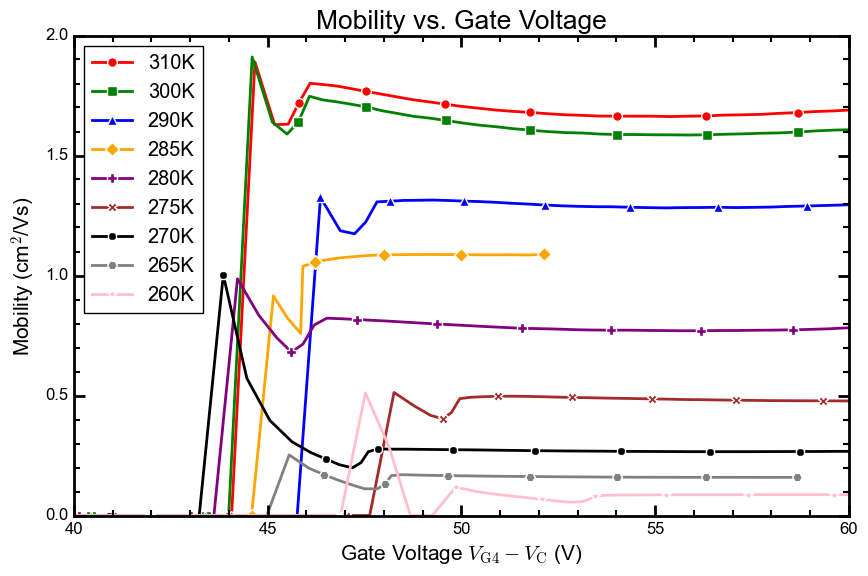

In [ ]:
for data, label, color, marker, mu, V_T in dataset:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = -data[:, 7]
    V_del = -(V_GS - V_C)
    mu_var = sigma / (Ci * (V_del - V_T)) * 1e4
    plt.plot(
        V_del,
        mu_var,
        color=color,
        marker=marker,
        markevery=5,
        ls='-',
        lw=2,
        label=label,
        markeredgecolor="white", markeredgewidth=1, markersize=7
    )

plt.xlabel(r"Gate Voltage $V_\text{G4} - V_\text{C}$ (V)")
plt.ylabel(r"Mobility (cm$^2$/Vs)")
plt.xlim(40,60)
plt.ylim(0, 2)  # Adjust y-axis limits for better visualization
plt.title("Mobility vs. Gate Voltage", fontsize=19)
plt.legend(numpoints=1, loc='upper left')
plt.show()

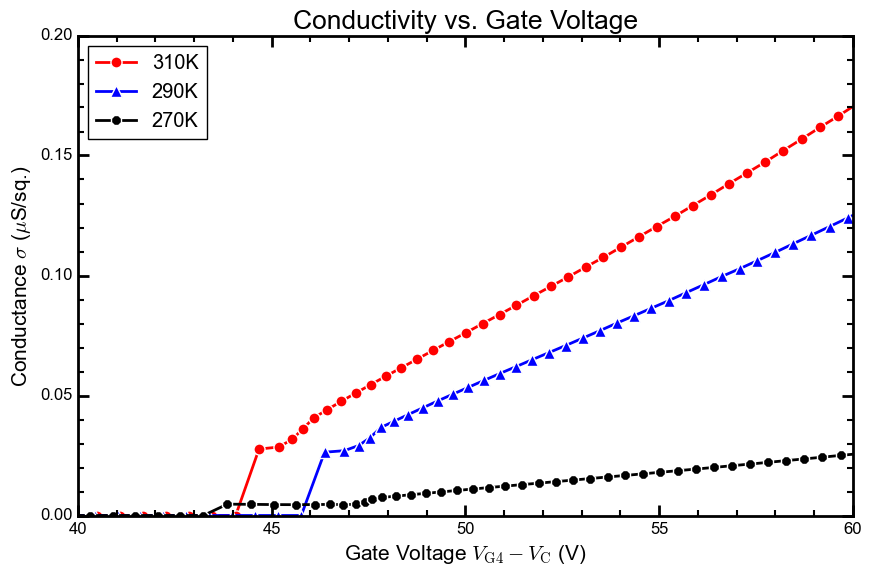

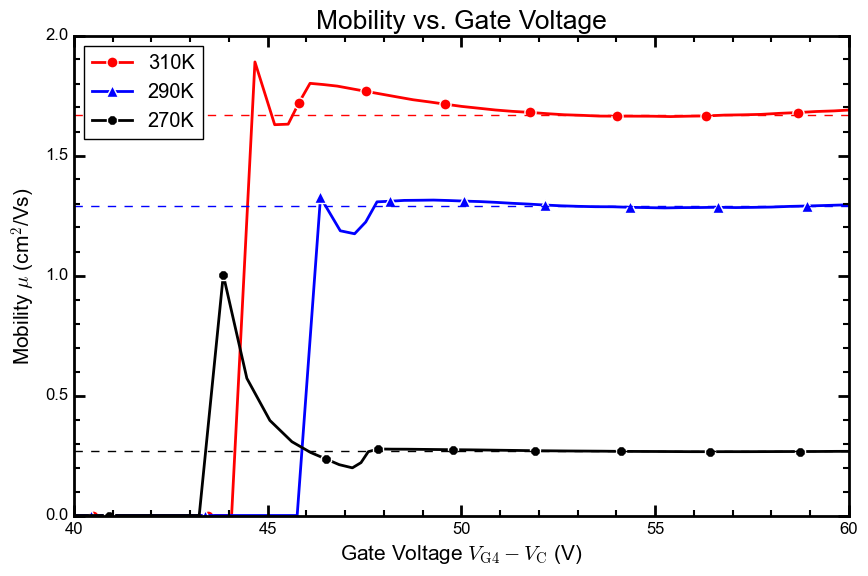

In [ ]:
selected_labels = {"310K", "290K", "270K"}

plt.figure()
for data, label, color, marker, mu, V_T in dataset:
    if label not in selected_labels:
        continue

    V_GS = data[:, 0]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    sigma = -data[:, 7]
    V_del = -(V_GS - V_C)

    plt.plot(
        V_del,
        sigma * 1e6,
        color=color,
        marker=marker,
        markevery=1,
        ls='-',
        lw=2,
        label=label,
        markeredgecolor="white",
        markeredgewidth=1,
        markersize=8,
    )

plt.xlabel(r"Gate Voltage $V_\text{G4} - V_\text{C}$ (V)")
plt.ylabel(r"Conductance $\sigma$ ($\mu$S/sq.)")
plt.xlim(40, 60)
plt.ylim(0, 0.20)
plt.title("Conductivity vs. Gate Voltage", fontsize=19)
plt.legend(numpoints=1, loc='upper left')
plt.savefig('sigma-1.eps', format='eps')
plt.show()

plt.figure()
for data, label, color, marker, mu, V_T in dataset:
    if label not in selected_labels:
        continue

    V_GS = data[:, 0]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    sigma = -data[:, 7]
    V_del = -(V_GS - V_C)
    mu_var = sigma / (Ci * (V_del - V_T)) * 1e4

    plt.plot(
        V_del,
        mu_var,
        color=color,
        marker=marker,
        markevery=5,
        ls='-',
        lw=2,
        label=label,
        markeredgecolor="white",
        markeredgewidth=1,
        markersize=8,
    )
    plt.axhline(y=mu, color=color, linestyle='--')

plt.xlabel(r"Gate Voltage $V_\text{G4} - V_\text{C}$ (V)")
plt.ylabel(r"Mobility $\mu$ (cm$^2$/Vs)")
plt.xlim(40, 60)
plt.ylim(0, 2)
plt.title("Mobility vs. Gate Voltage", fontsize=19)
plt.legend(numpoints=1, loc='upper left')
plt.savefig('muvar-1.eps', format='eps')
plt.show()